<h1 style="font-size: 24px;">K-means clustering - example I</h1>

1,2,3

In [64]:
from sklearn.datasets import make_blobs 
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
 
# help(make_blobs)
x, y = make_blobs(n_samples=120, centers=4, n_features=2,cluster_std=0.4)
print(x.shape)
print(y.shape)

(120, 2)
(120,)


4

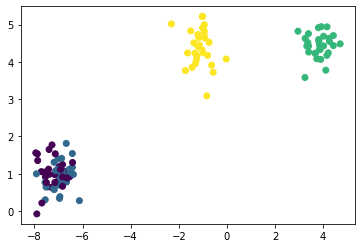

In [3]:
plt.scatter(x[:,0],x[:,1],c=y)

5

In [4]:
cls=KMeans(n_clusters=4,n_init='auto')
cls.fit(x)
y_pred=cls.predict(x)


6,7

34.879350265546485


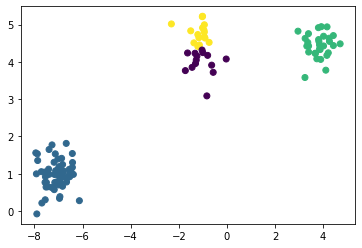

In [5]:
plt.scatter(x[:,0],x[:,1],c=y_pred)
print(cls.inertia_)

<h1 style="font-size: 24px;">K-means clustering - example II</h1>

1

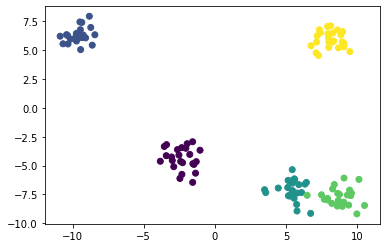

In [6]:
x, y = make_blobs(n_samples=120, centers=5, n_features=2,cluster_std=0.8)
plt.scatter(x[:,0],x[:,1],c=y)

2

138.51492337469648


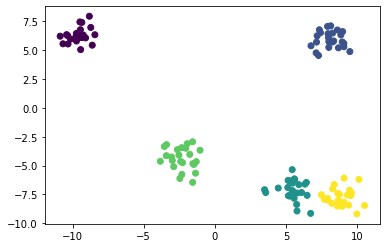

In [7]:
cls=KMeans(n_clusters=5,init='random',n_init='auto')
cls.fit(x)
y_pred=cls.predict(x)
plt.scatter(x[:,0],x[:,1],c=y_pred)
print(cls.inertia_)

3,4

4895.785079960757


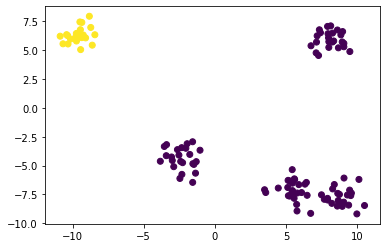

In [8]:
cls=KMeans(n_clusters=2,init='random',n_init='auto')
cls.fit(x)
y_pred=cls.predict(x)
plt.scatter(x[:,0],x[:,1],c=y_pred)
print(cls.inertia_)

<h1 style="font-size: 24px;">K-means ++ </h1>

138.51492337469648


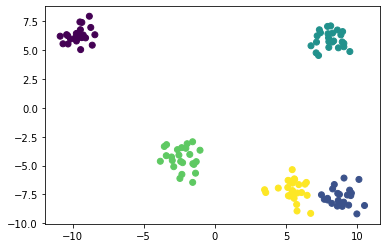

In [9]:
cls=KMeans(n_clusters=5,init='k-means++',n_init='auto')
cls.fit(x)
y_pred=cls.predict(x)
plt.scatter(x[:,0],x[:,1],c=y_pred)
print(cls.inertia_)

5614.987295623193


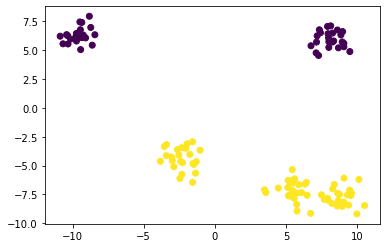

In [10]:
cls=KMeans(n_clusters=2,init='k-means++',n_init='auto')
cls.fit(x)
y_pred=cls.predict(x)
plt.scatter(x[:,0],x[:,1],c=y_pred)
print(cls.inertia_)

<h1 style="font-size: 24px;">Elbow method </h1>

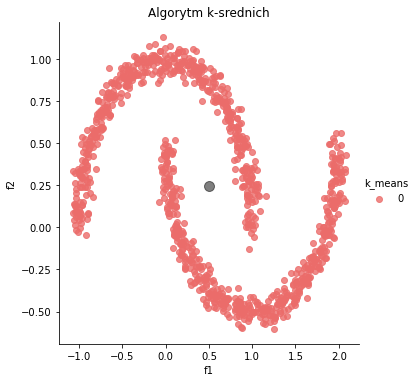

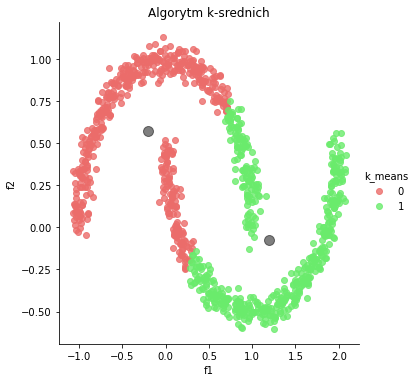

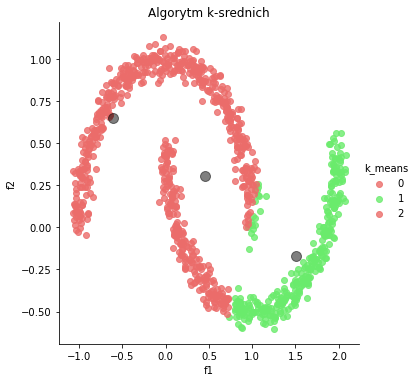

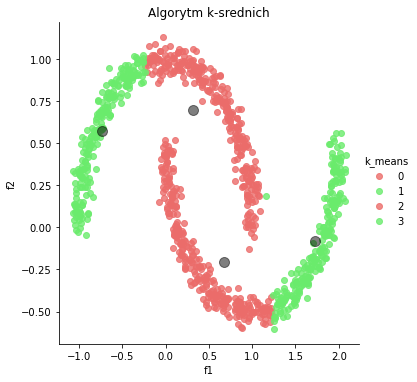

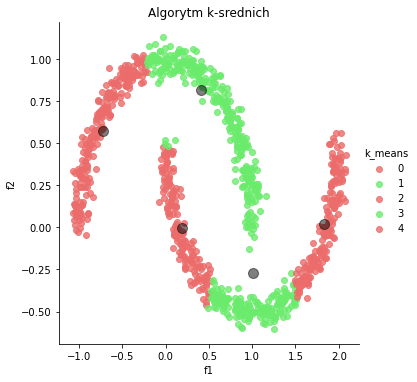

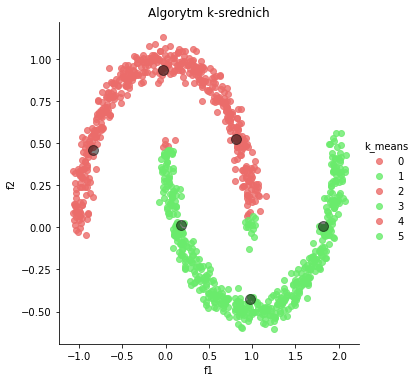

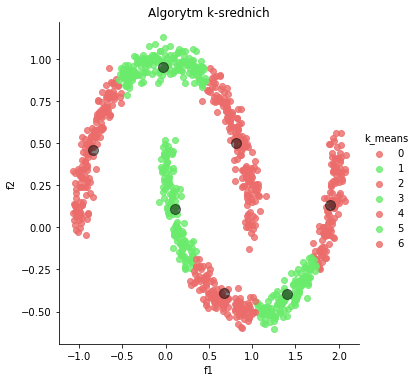

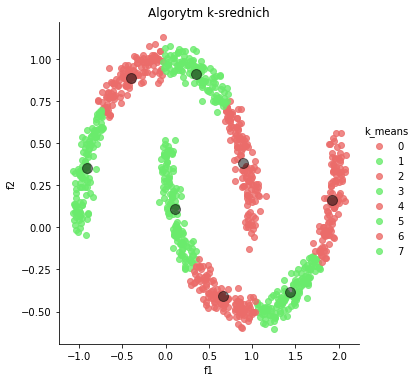

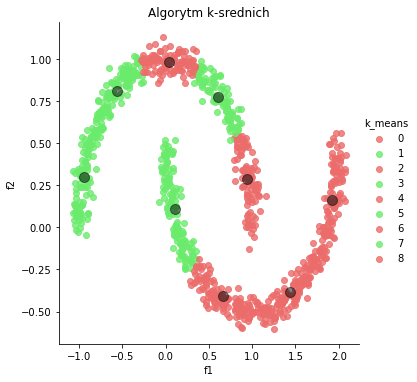

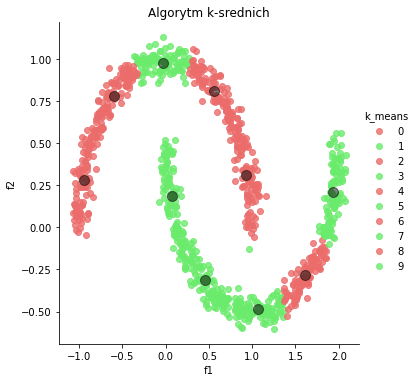

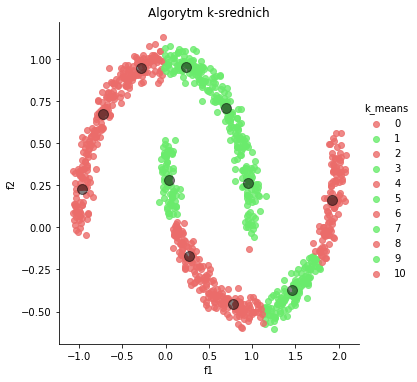

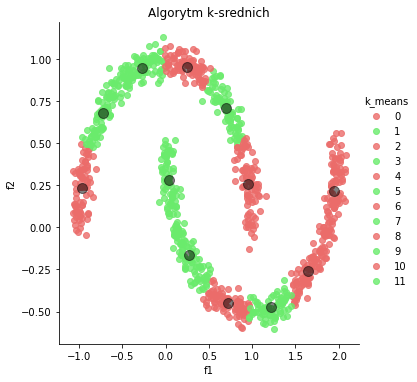

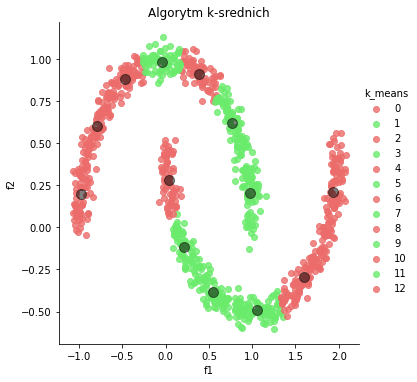

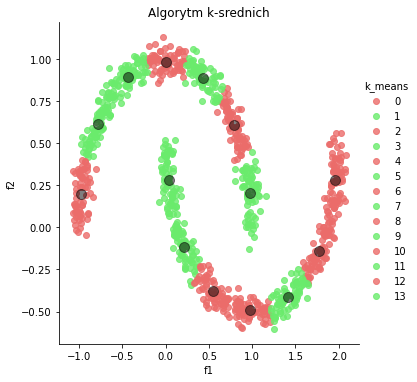

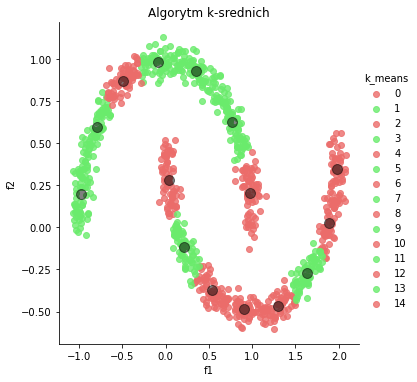

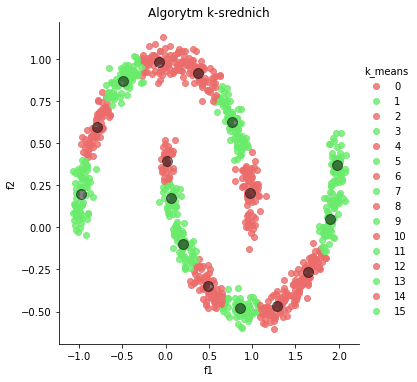

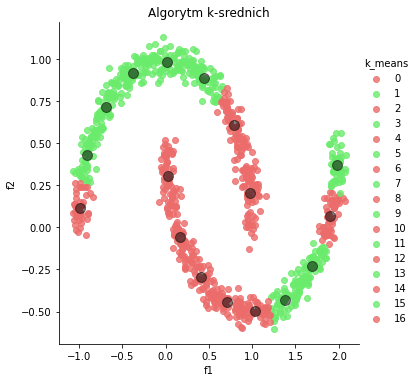

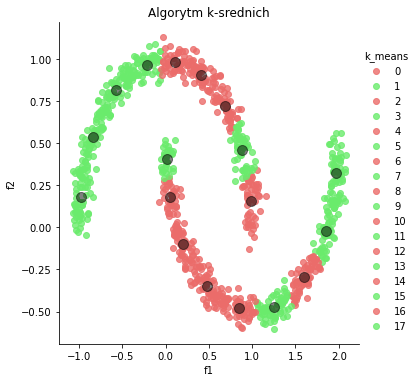

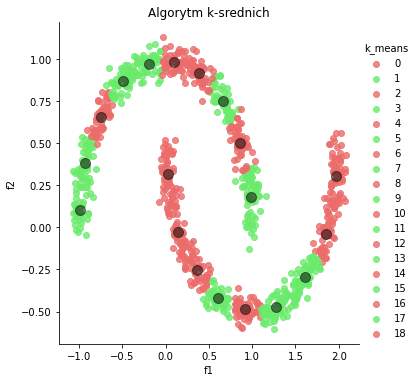

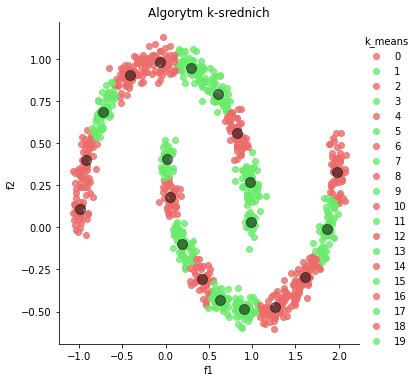

In [11]:
from sklearn.datasets import make_moons
import seaborn as sns
import pandas as pd

# fig,ax=plt.subplots(5,4,figsize=(5*4,4*4)) 
x, y = make_moons(1000, noise=.05, random_state=0)
X_moon = pd.DataFrame(x, columns = ['f1','f2'])
#TODO: Kmeans
distortions=[]
for i in range(20):
    kmean=KMeans(n_clusters=i+1,init='k-means++',n_init='auto')
    kmean.fit(x)
    y_km=kmean.predict(x)
    distortions.append(kmean.inertia_)
    centers=kmean.cluster_centers_
    #Plot
    X_moon['k_means'] = y_km
    sns.lmplot(data=X_moon, x='f1', y='f2', fit_reg=False, hue = 'k_means', palette = ['#eb6c6a', '#6aeb6c']).set(title='Algorytm k-srednich')
    plt.scatter(centers[:, 0], centers[:, 1], c='black', s=100, alpha=0.5)
    plt.show()

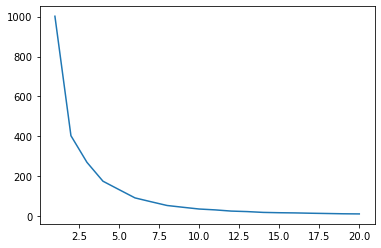

In [12]:
import numpy as np
x=np.arange(1,21)
plt.plot(x,distortions)

Z obserwacji wykresów z klastrami 8 jest wystarczająca, zwiększanie ich ilości od tego momentów nic nie zmienia, ale wartość inercji będzie i tak spadać wraz ze zwiększaniem się ilości klastrów.
Na podstawie wykresu powyżej wybrałbym 6 - i błędy są tam już faktycznie, z mojej pomijalnie niewielkie.

<h1 style="font-size: 24px;">Clustering II - hierarchical methods</h1>

Dendrograms

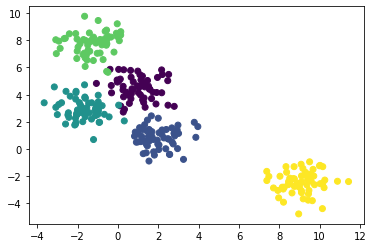

In [13]:
X, y_true = make_blobs(n_samples=300, centers=5,cluster_std=0.8, random_state=0)
plt.scatter(X[:,0],X[:,1],c=y_true)

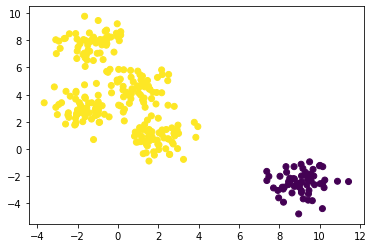

In [14]:
cls=KMeans(n_clusters=2,init='k-means++',n_init='auto')
cls.fit(X)
y_pred=cls.predict(X)
plt.scatter(X[:,0],X[:,1],c=y_pred)

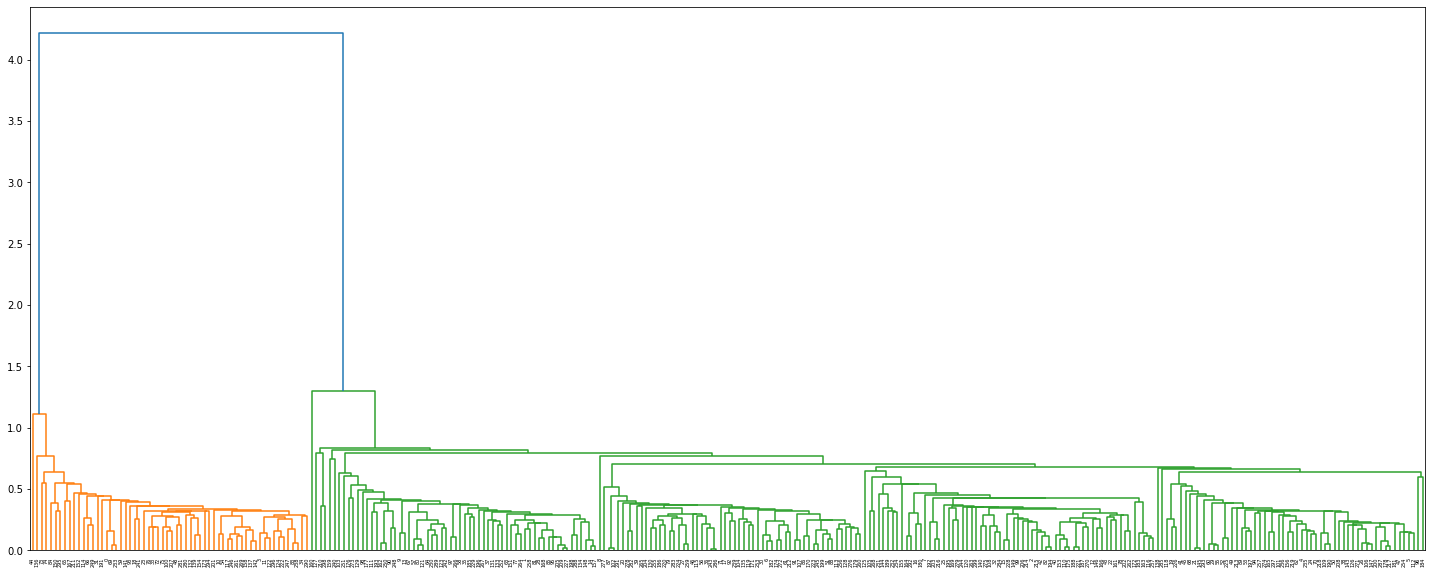

In [15]:
from scipy.cluster.hierarchy import dendrogram, linkage
Z = linkage(X)
fig = plt.figure(figsize=(25, 10))
dn = dendrogram(Z)


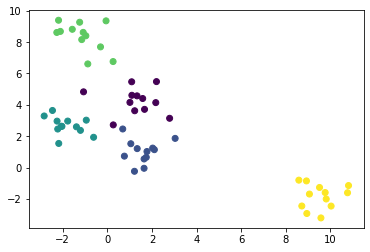

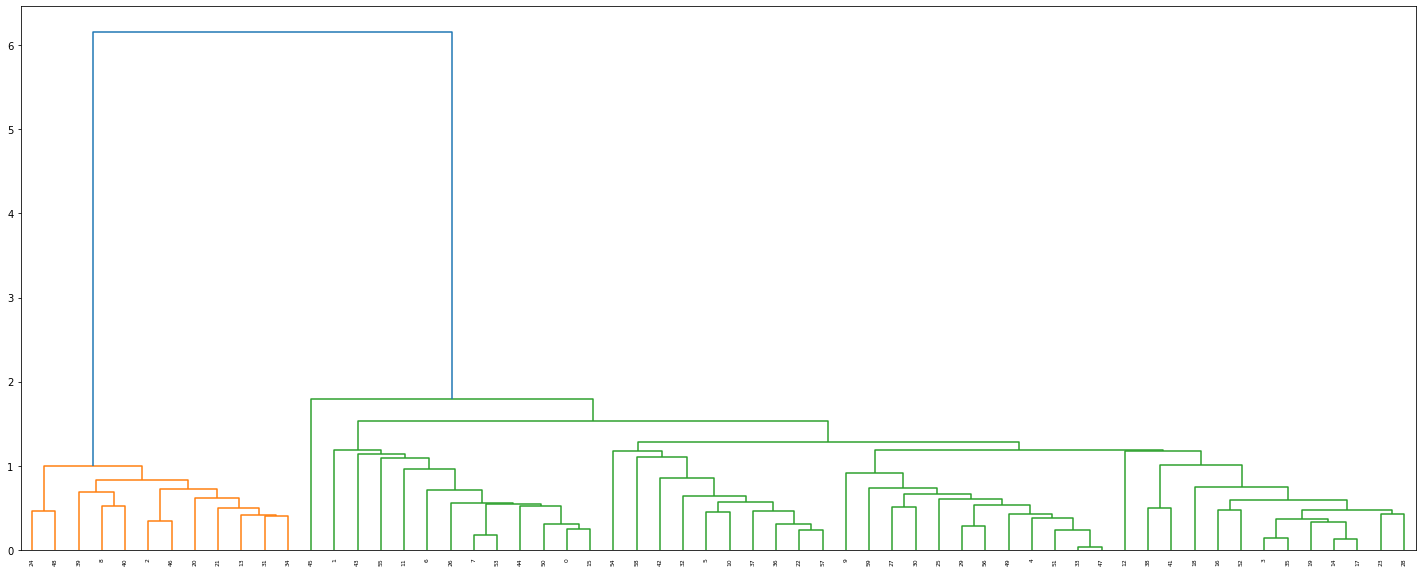

In [16]:
X, y_true = make_blobs(n_samples=60, centers=5,cluster_std=0.8, random_state=0)
plt.scatter(X[:,0],X[:,1],c=y_true)
Z = linkage(X)
fig = plt.figure(figsize=(25, 10))
dn = dendrogram(Z)

Agglomerative clustering

1-7

In [17]:
df = pd.read_csv('shopping_data (1).csv')
print(df)

     CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]


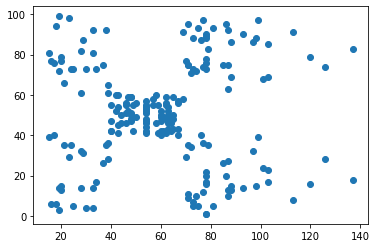

In [31]:
X=[df['Annual Income (k$)'],df['Spending Score (1-100)']]
X1=np.column_stack((X[0],X[1]))
plt.scatter(X1[:,0],X1[:,1])

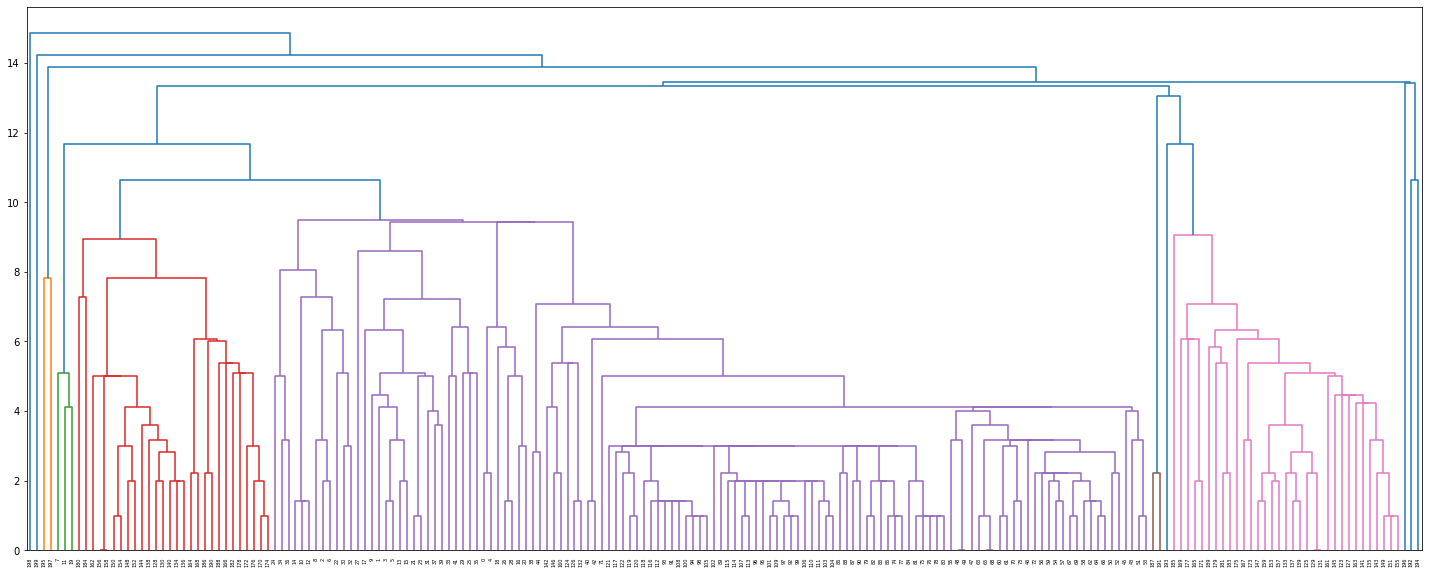

In [29]:
Z = linkage(X1,method='single')
fig = plt.figure(figsize=(25, 10))
dn = dendrogram(Z)

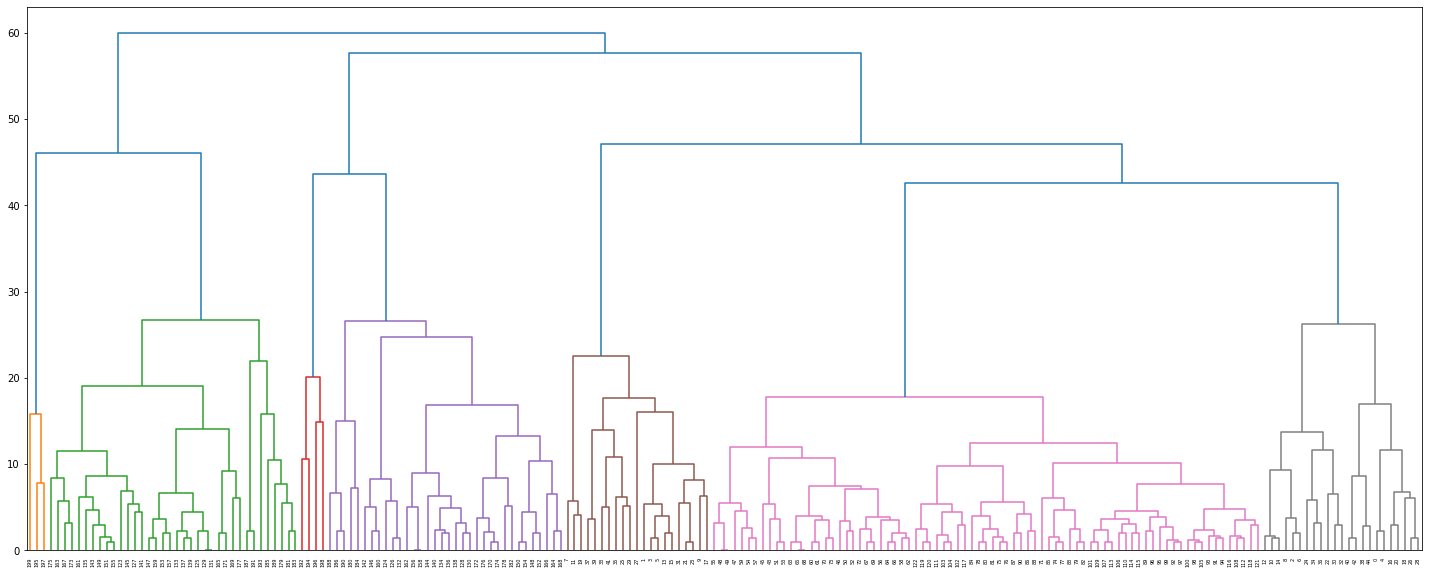

In [38]:
Z1 = linkage(X1,method='average')
fig = plt.figure(figsize=(25, 10))
dn = dendrogram(Z1)

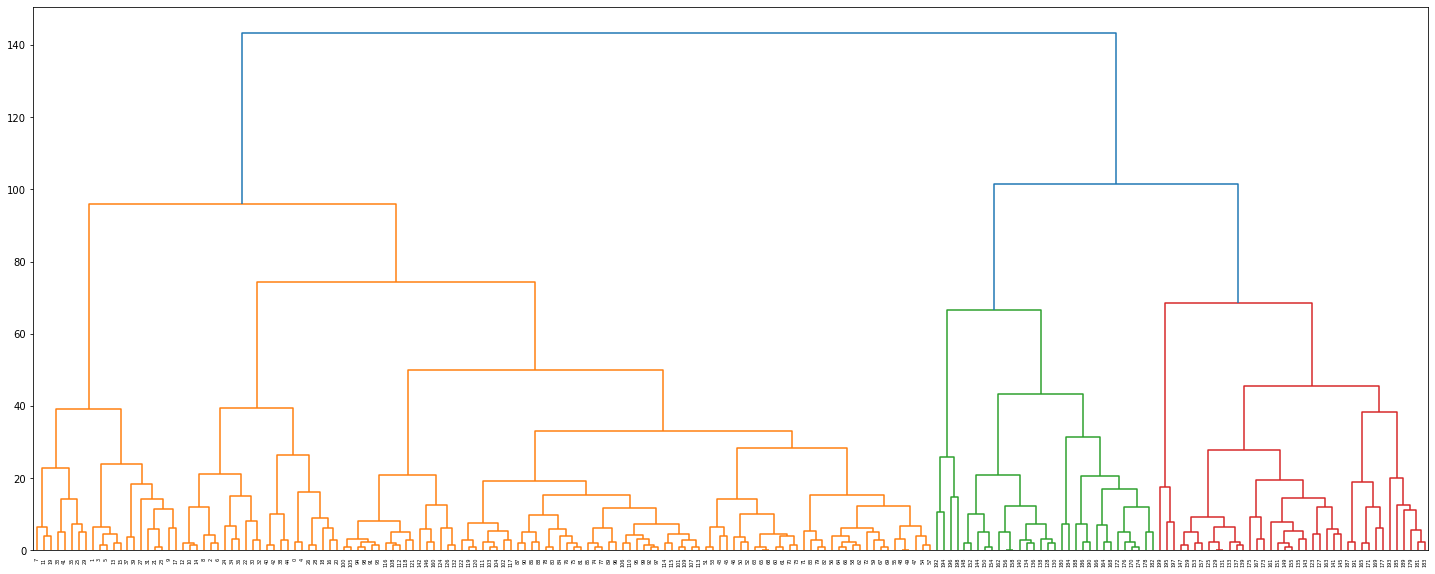

In [39]:
Z2 = linkage(X1,method='complete')
fig = plt.figure(figsize=(25, 10))
dn = dendrogram(Z2)

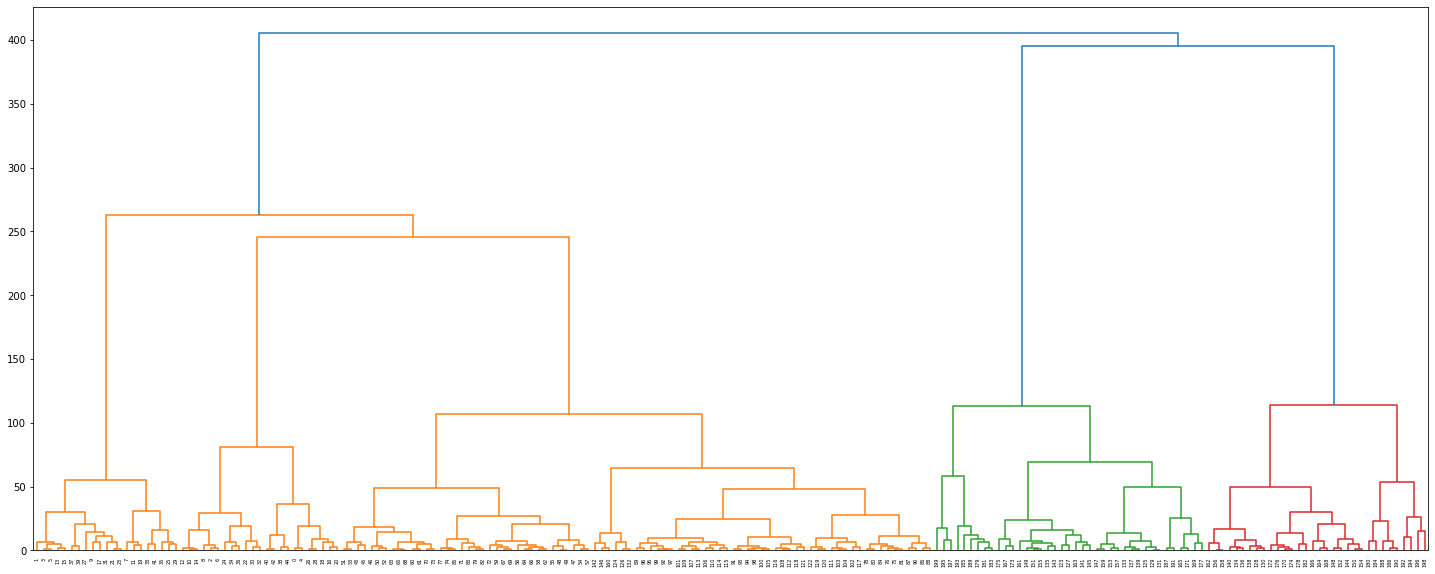

In [40]:
Z3 = linkage(X1,method='ward')
fig = plt.figure(figsize=(25, 10))
dn = dendrogram(Z3)


8,9

In [83]:
def make_colour(yy):
    colors = np.array(
                list(
                    islice(
                        cycle(
                            [
                                "#377eb8",
                                "#ff7f00",
                                "#4daf4a",
                                "#f781bf",
                                "#a65628",
                                "#984ea3",
                                "#999999",
                                "#e41a1c",
                                "#dede00",
                            ]
                        ),
                        int(max(yy) + 1),
                    )
                )
    )
    return colors

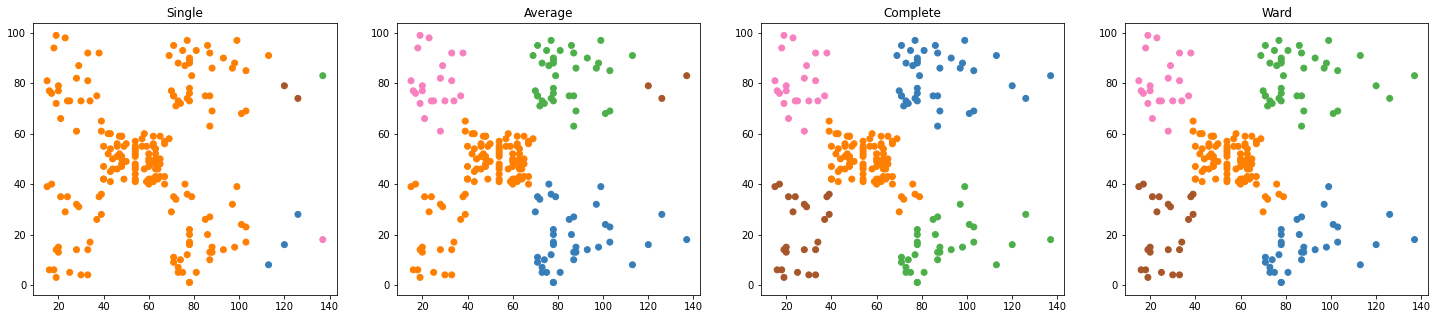

In [90]:
from sklearn.cluster import AgglomerativeClustering
from itertools import cycle, islice

methods=['Single','Average', 'Complete','Ward']
fig,ax=plt.subplots(1,4,figsize=(25,5))
for i in range(len(methods)):
    clustering = AgglomerativeClustering(n_clusters=5,linkage=methods[i].lower()).fit(X1)
    yy=clustering.labels_
    colors=make_colour(yy)
    ax[i].scatter(X1[:,0],X1[:,1],color=colors[yy])
    ax[i].set_title(methods[i])



Selecting the number of clusters with silhouette analysis on KMeans clustering

In [95]:
from sklearn.metrics import silhouette_score,silhouette_samples

X, y = make_blobs(n_samples=500,
                  n_features=2,
                  centers=4,
                  cluster_std=1,
                  center_box=(-10.0, 10.0),
                  shuffle=True,
                  random_state=1) 

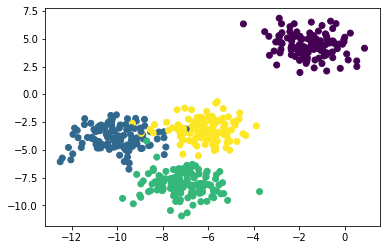

In [111]:

plt.scatter(X[:,0],X[:,1],c=y)

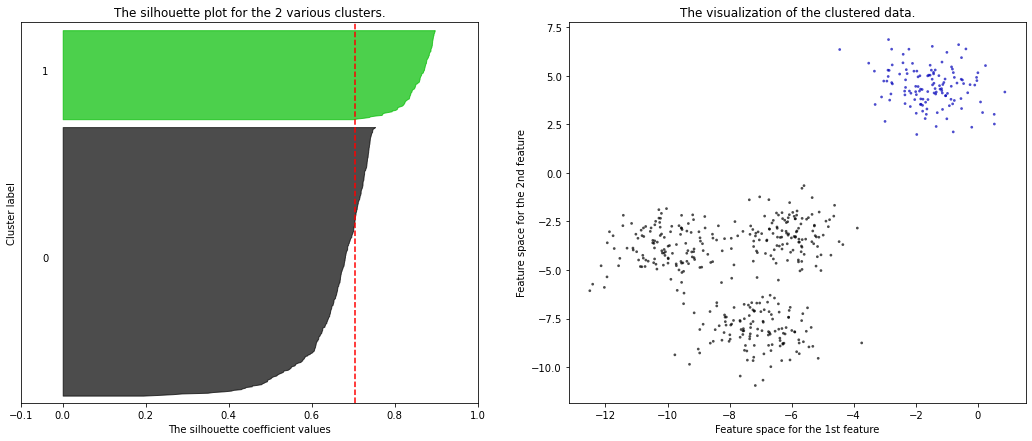

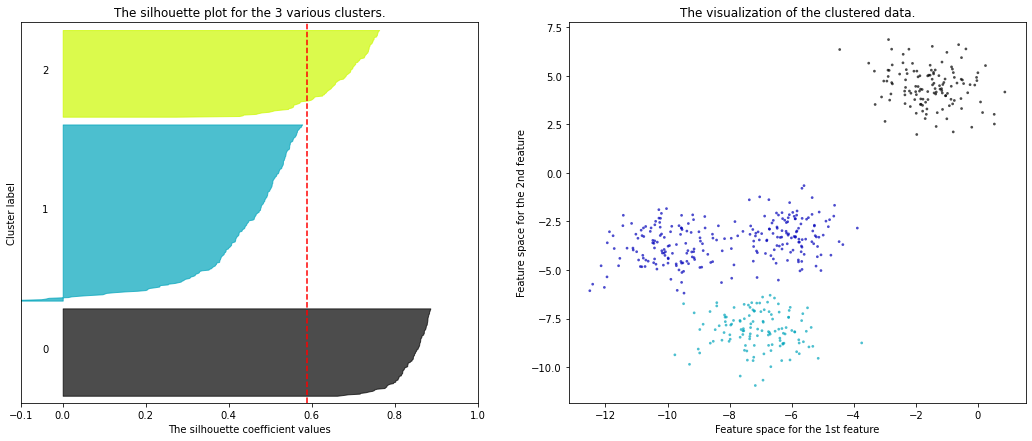

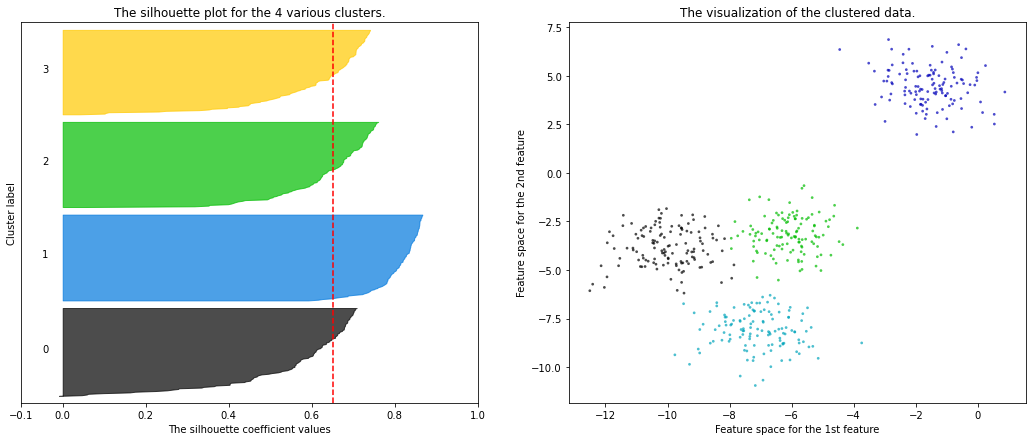

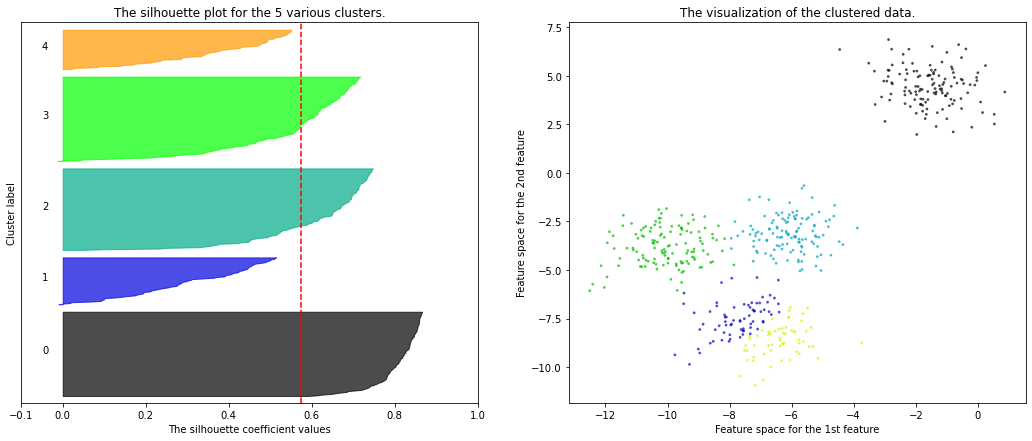

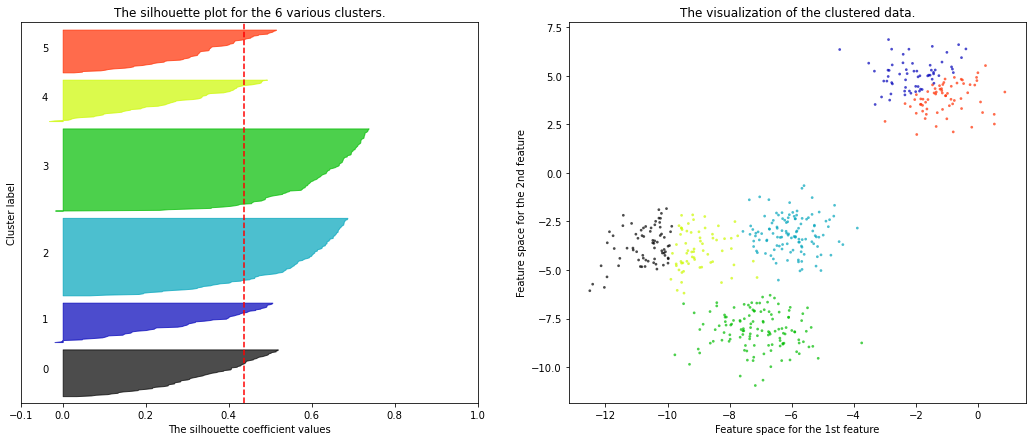

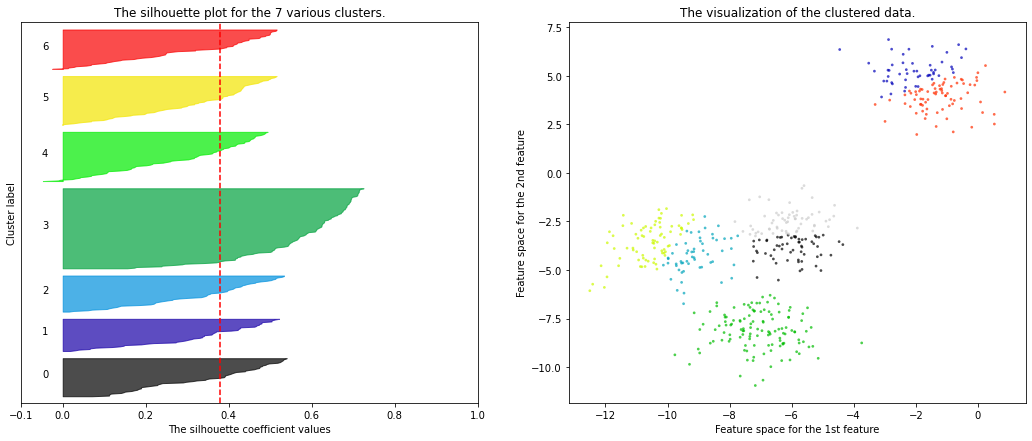

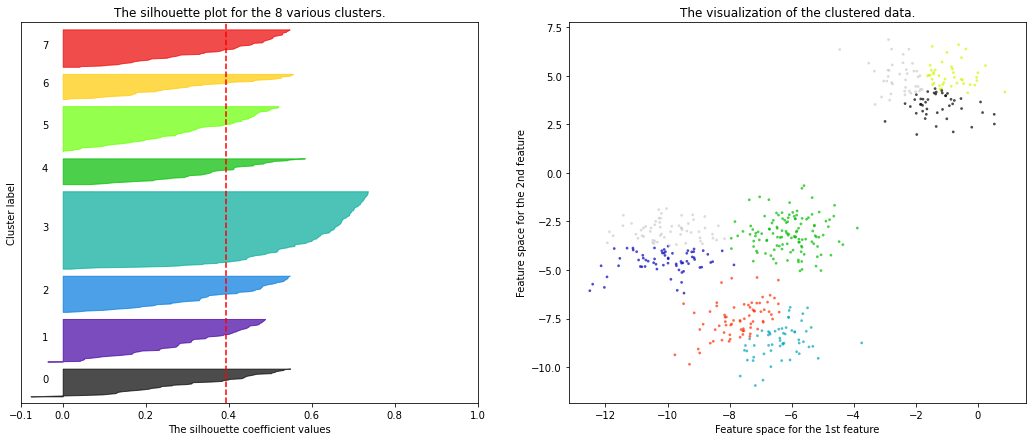

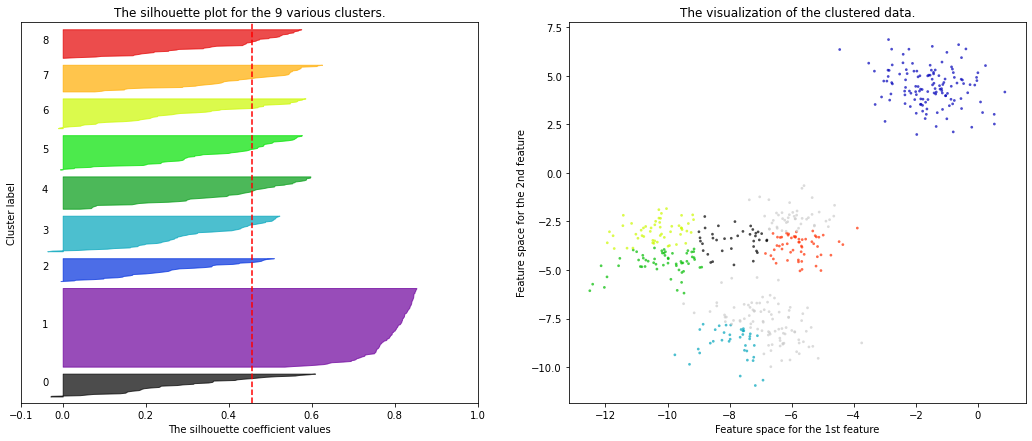

In [134]:
import matplotlib.cm as cm



score=[]
samples_score=[]
for j in range(2,10):
    kmean=KMeans(n_clusters=j,init='k-means++',n_init='auto')
    kmean.fit(X)
    cluster_labels=kmean.predict(X)
    score.append(silhouette_score(X, cluster_labels))
    silhouette_avg=score[-1]
    sample_silhouette_values = silhouette_samples(X, cluster_labels)
    samples_score.append(sample_silhouette_values)

    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)
    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X) + (j + 1) * 10])

    y_lower = 10
    for i in range(j):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / j)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the {} various clusters.".format(j))
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        X[:, 0], X[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")


Text(0.5, 0, 'number of clusters')

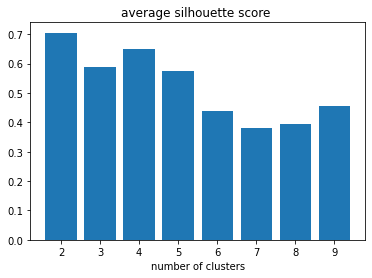

In [138]:
x=np.arange(2,10)
plt.bar(x,score)
plt.title('average silhouette score ')
plt.xlabel('number of clusters')

<h1 style="font-size: 24px;">DBSCAN - density based clusterring </h1>

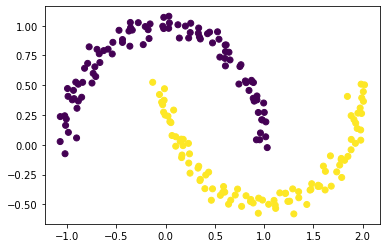

In [143]:
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.cluster import DBSCAN
x, y = make_moons(n_samples=200, noise=.05, random_state=0)
plt.scatter(x[:,0],x[:,1],c=y)
plt.show()

In [155]:
scan=DBSCAN(eps=0.2,min_samples=4)
scan.fit_predict(x)
y_pred=scan.labels_

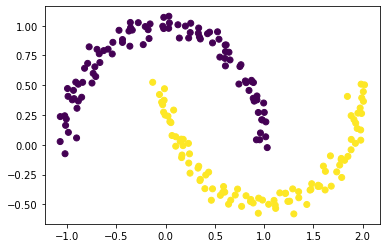

In [156]:
plt.scatter(x[:,0],x[:,1],c=y_pred)

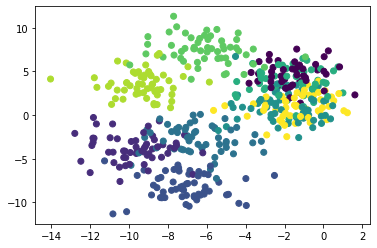

In [162]:
x, y = make_blobs(n_samples=500,n_features=2,centers=9,cluster_std=1.5,
                #   center_box=(-10.0, 10.0),
                  shuffle=True,
                  random_state=1) 
plt.scatter(x[:,0],x[:,1],c=y)

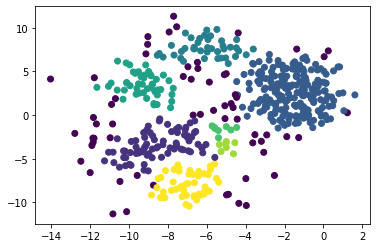

In [173]:
scan=DBSCAN(eps=0.9,min_samples=6)
scan.fit_predict(x)
y_pred=scan.labels_
plt.scatter(x[:,0],x[:,1],c=y_pred)

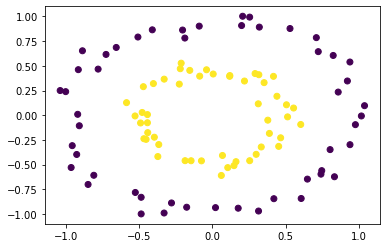

In [198]:
x,y=make_circles(n_samples=100, noise=0.07, random_state=1, factor=0.5)
plt.scatter(x[:,0],x[:,1],c=y)


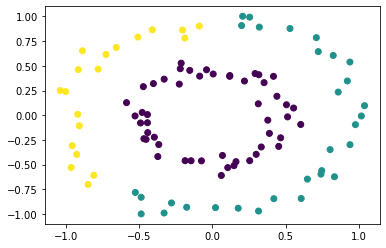

In [231]:
scan=DBSCAN(eps=0.25,min_samples=2)
scan.fit_predict(x)
y_pred=scan.labels_
plt.scatter(x[:,0],x[:,1],c=y_pred)